<a href="https://colab.research.google.com/github/HeberBernal/Bankchurners/blob/main/Bankchurners.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###**Carga, Limpieza y Preparación del Dataset.**

In [ ]:
#Carga del Dataset
import pandas as pd
ruta = '/content/BankChurners (1).xlsx'
df = pd.read_excel(ruta)

#limpieza, se descartan CLIENTNUM y columnas de Naive Bayes.
cols_ruido = [col for col in df.columns if 'Naive_Bayes' in col] + ['CLIENTNUM']
df = df.drop(columns=cols_ruido)

#Verificación de la estructura limpia
df.head()

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


###**Tópico 1. Análisis de bases de datos**

Se identificaron **10127** registros y **20** variables del conjunto de datos BankChurners.csv para ser utilizados en el analisis.






In [ ]:
# Contabilizador de Numero de registros.
num_registros = df.shape[0]
# Contabilizador de Numero de variables.
num_variables = df.shape[1]

print(f"*El conjunto de datos tiene {num_registros} registros.")
print(f"*Identificación de {num_variables} variables del conjunto de datos BankChurners.csv")
print("-" * 50)

#Conteo de las columnas que utilizaremos como variables.
print("LISTADO DE COLUMNAS:")
print("\n".join(df.columns.tolist()))

# Usamos .str.strip() por si acaso hay espacios invisibles
# y value_counts() para el conteo rápido
conteo = df['Gender'].value_counts()

print("--- Conteo de Clientes por Género ---")
print(conteo)

print("\n--- Porcentaje por Género ---")
print(df['Gender'].value_counts(normalize=True) * 100)

*El conjunto de datos tiene 10127 registros.
*Identificación de 20 variables del conjunto de datos BankChurners.csv
--------------------------------------------------
LISTADO DE COLUMNAS:
Attrition_Flag
Customer_Age
Gender
Dependent_count
Education_Level
Marital_Status
Income_Category
Card_Category
Months_on_book
Total_Relationship_Count
Months_Inactive_12_mon
Contacts_Count_12_mon
Credit_Limit
Total_Revolving_Bal
Avg_Open_To_Buy
Total_Amt_Chng_Q4_Q1
Total_Trans_Amt
Total_Trans_Ct
Total_Ct_Chng_Q4_Q1
Avg_Utilization_Ratio
--- Conteo de Clientes por Género ---
Gender
F    5358
M    4769
Name: count, dtype: int64

--- Porcentaje por Género ---
Gender
F    52.908068
M    47.091932
Name: proportion, dtype: float64


**¿Qué comando utilizas para identificar a las variables con datos nulos?**

El comando estándar de Pandas es **df.isnull().sum()**, para verificar que no hay celdas vacias. Sin embargo aunque el dataset no presenta celdas vacías (NaN) se identificó ruido en los datos bajo la etiqueta 'Unknown' en variables como Education_Level,Income_Category y Marital_Status, lo cual se consideró en el análisis descriptivo.

In [ ]:
#Verificación de datos Null(Celdas vacias)
df.isnull().sum()

,0
Attrition_Flag,0
Customer_Age,0
Gender,0
Dependent_count,0
Education_Level,0
Marital_Status,0
Income_Category,0
Card_Category,0
Months_on_book,0
Total_Relationship_Count,0


Para responder a la pregunta: **¿Cuál es la variable con más null?** e identificar los datos bajo la etiqueta 'Unknown' , Se opto por utilizar el comando **conteo = (df[col] == 'Unknown').sum()** para capturar el total de Valores 'Unknown' con respecto a la muestra.


**¿Cuál es la variable con más null?**

La variable más afectada con la etiqueta 'Unknown' es **Education_Level con 1,519 registros (14.99)**,
seguida de Income_Category con 1,112 registros (10.98%) y
Marital_Status con 749 registros (7.40%).



**¿Qué recomiendas hacer en caso de encontrar datos nulos?**
Al detectar valores nulos o no informados ('Unknown'), se debe evaluar el impacto de su eliminación en el conjunto de datos. Si representan menos del 5%, su eliminación es viable ya que se considera ruido estadístico menor. Sin embargo, en este caso representan aproximadamente el **15%** del total de registros. Mantener estos datos es fundamental para **preservar la representatividad de la muestra.**

In [ ]:
# Identificación de valores 'Unknown' en variables categóricas
unknowns = []

for col in df.columns:
    if df[col].dtype == 'object':
        conteo = (df[col] == 'Unknown').sum()
        if conteo > 0:
            # Se guardan los resultados en una lista de diccionarios.
            unknowns.append({'Variable': col, 'Cantidad_Unknown': conteo})

# Se Convirtió la lista en un DataFrame para un output mas legible.
df_unknowns = pd.DataFrame(unknowns)
# Calculamos el porcentaje para que observar la parte de la muestra que representan los valores Unknown.
df_unknowns['Porcentaje (%)'] = (df_unknowns['Cantidad_Unknown'] / len(df)) * 100

print("Valores Unknown encontrados en conjunto de datos BankChurners.csv:")

#Para mayor legibilidad en los datos utilizamos y evitar los valores index

display(df_unknowns.set_index('Variable').sort_values(by='Cantidad_Unknown', ascending=False))


Valores Unknown encontrados en conjunto de datos BankChurners.csv:


,Cantidad_Unknown,Porcentaje (%)
Variable,,
Education_Level,1519,14.999506
Income_Category,1112,10.980547
Marital_Status,749,7.396070


###**Tópico 2. Análisis descriptivo de las variables**

**Obtención de las medidas descriptivas cuantitativas**

In [ ]:
#Obtención de medidas descriptivas.
print("MEDIDAS DESCRIPTIVAS CUANTITATIVAS")
df_num = df.describe().T
df_num['median'] = df.median(numeric_only=True)
display(df_num[['count', 'mean', 'median', 'std', 'min', 'max']])

# Comparar el promedio de Saldo Revolvente por Género
comparativo_revolvente = df.groupby('Gender')['Total_Revolving_Bal'].mean()

print("--- Promedio de Saldo Revolvente por Género ---")
print(comparativo_revolvente)

# Crear una tabla cruzada de Género vs Categoría de Ingresos
comparativa_ingresos = pd.crosstab(df['Gender'], df['Income_Category'])

# Verlo en porcentajes para que sea más claro
comparativa_pct = pd.crosstab(df['Gender'], df['Income_Category'], normalize='index') * 100


MEDIDAS DESCRIPTIVAS CUANTITATIVAS


,count,mean,median,std,min,max
Customer_Age,10127.0,46.325960,46.000,8.016814,26.0,73.000
Dependent_count,10127.0,2.346203,2.000,1.298908,0.0,5.000
Months_on_book,10127.0,35.928409,36.000,7.986416,13.0,56.000
Total_Relationship_Count,10127.0,3.812580,4.000,1.554408,1.0,6.000
Months_Inactive_12_mon,10127.0,2.341167,2.000,1.010622,0.0,6.000
Contacts_Count_12_mon,10127.0,2.455317,2.000,1.106225,0.0,6.000
Credit_Limit,10127.0,8631.953698,4549.000,9088.776650,1438.3,34516.000
Total_Revolving_Bal,10127.0,1162.814061,1276.000,814.987335,0.0,2517.000
Avg_Open_To_Buy,10127.0,7469.139637,3474.000,9090.685324,3.0,34516.000
Total_Amt_Chng_Q4_Q1,10127.0,0.759941,0.736,0.219207,0.0,3.397


--- Promedio de Saldo Revolvente por Género ---
Gender
F    1140.011198
M    1188.433215
Name: Total_Revolving_Bal, dtype: float64


**Obtención de las medidas descriptivas cualitativas**

In [ ]:
#Obtención de medidas descriptivas.
print("MEDIDAS DESCRIPTIVAS: VARIABLES CUALITATIVAS")
df_cat = df.describe(include='object').T
display(df_cat)

MEDIDAS DESCRIPTIVAS: VARIABLES CUALITATIVAS


,count,unique,top,freq
Attrition_Flag,10127,2,Existing Customer,8500
Gender,10127,2,F,5358
Education_Level,10127,7,Graduate,3128
Marital_Status,10127,4,Married,4687
Income_Category,10127,6,Less than $40K,3561
Card_Category,10127,4,Blue,9436


Los tipos de variables que se obtuvieron son:

•	**Cualitativas Nominales:** Attrition_Flag, Gender, Marital_Status.

•	**Cualitativas Ordinales:** Education_Level, Income_Category (presentan un orden jerárquico de valor/instrucción).

•	**Cuantitativas Discretas:** Customer_Age, Dependent_count, Total_Relationship_Count, Months_on_book.

•	**Cuantitativas Continuas:** Credit_Limit, Avg_Utilization_Ratio, Total_Revolving_Bal.

###**Tópico 3. Análisis inferencial**

**Genere la matriz de correlación de la tabla de datos.**


In [ ]:
#Generación de matriz para correlación de la tabla de datos.
# 1. Calculamos la matriz de correlación (Coeficiente de Pearson)
# Se calculan las correlaciones filtrando solo las columnas numéricas para evitar errores con texto.
# Análisis Inferencial
import numpy as np
corr_matrix = df.corr(numeric_only=True)


**Guía para interpretación de Grafico (Mapa de calor)**

**Rojo Intenso** (Cercano a +1.0): Existe una Correlación Positiva Fuerte. Significa que cuando una variable aumenta, la otra también lo hace. (Ejemplo: A más compras, más gasto total).

**Azul Intenso** (Cercano a -1.0): Existe una Correlación Negativa (Inversa) Fuerte. Significa que cuando una variable aumenta, la otra disminuye. (Ejemplo: A mayor límite de crédito, menor es el porcentaje de uso de la tarjeta).

**Blanco/Gris** (Cercano a 0): Sin Correlación. Las variables son independientes; lo que pase con una no afecta a la otra. (Ejemplo: La edad no influye en cuántas veces se bloquea la tarjeta).

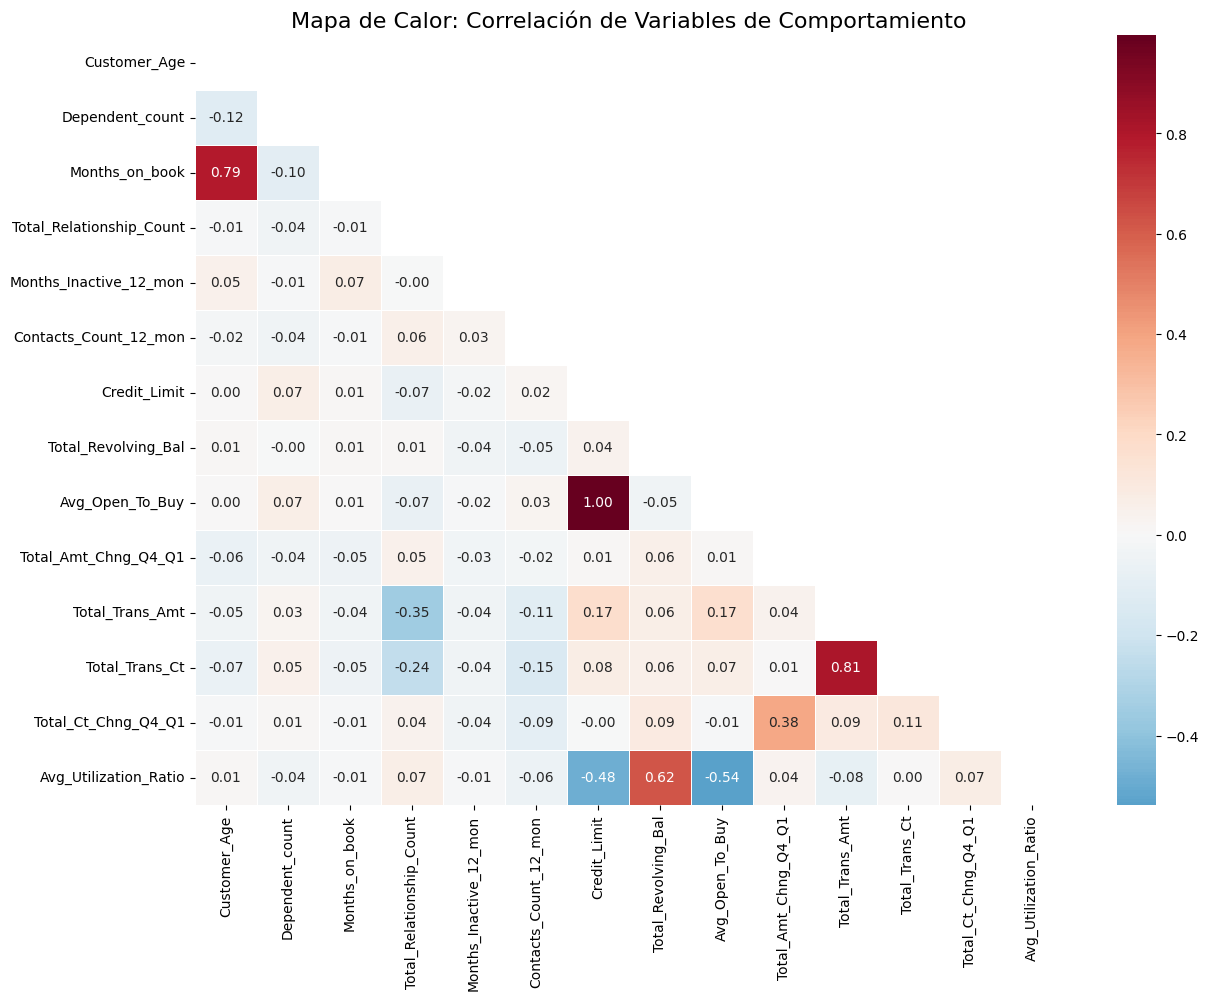

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings

#Se eliminaron los warnings para mantener una mejor visualizacion del grafico
warnings.filterwarnings('ignore')

# 1. Preparación de datos
corr_matrix = df.corr(numeric_only=True)

# 2. Configuración del lienzo
plt.figure(figsize=(14, 10))

# 3. Máscara (Triangular) para reducir ruido visual
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 4. Heatmap con parámetros de alta precisión
sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            fmt=".2f",
            cmap='RdBu_r',
            center=0,
            linewidths=0.5) # Agregué esto para que los cuadros se vean más definidos

plt.title('Mapa de Calor: Correlación de Variables de Comportamiento', fontsize=16)
plt.show()

**Análisis de Hallazgos: Correlaciones Críticas de Negocio**

1. Al observar la matriz de correlación se puede notar que el cruce entre Monto Total de Transacciones (Total_Trans_Amt) y Cantidad Total de Transacciones (Total_Trans_Ct) tiene una correlación muy alta de **0.81.**


2. **Explicación de la causa de correlación entre Total_Trans_Amt y Total_Trans_Ct**: Este valor de **0.81** indica que, a medida que los clientes realizan más transacciones, el monto total gastado aumenta de forma casi lineal, lo que valida la actividad transaccional como motor principal del gasto.

3. **Se calculó el coeficiente de correlación** entre las variables Avg_Utilization_Ratio (Razón de uso promedio de la tarjeta) y Total_Revolving_Bal (Saldo revolvente total en la tarjeta de crédito) el cual fue de **0.62.**

4. **Explicación de la causa de correlación entre Avg_Utilization_Ratio y Total_Revolving_Bal**:
La causa de esta correlación (**0.62**) es la dependencia directa del infice de Utilización respecto al Saldo Revolvente. Este valor confirma que el endeudamiento persistente de los clientes está ligado al agotamiento de su límite disponible, reflejando un perfil que usa el crédito como financiamiento a largo plazo y no solo como medio de pago diario.





**Interpretación del Gráfico de Cajas (Boxplot)**

Este gráfico permite visualizar la dispersión y los cuartiles del Límite de Crédito segmentado por género. Para su correcta interpretación, observamos los siguientes componentes:

**Línea Central (Mediana):** Indica el valor central de la distribución. Se observa que la mediana de los hombres es significativamente superior a la de las mujeres, lo que refleja una tendencia inicial de mayores líneas de crédito para el segmento masculino.

**Caja (Rango Intercuartílico):** Representa donde se concentra el 50% de los clientes. La caja masculina es mucho más amplia y está desplazada hacia arriba, indicando una mayor variabilidad y acceso a montos elevados.

**Bigotes y Valores Atípicos:** Los puntos por encima de los bigotes representan clientes con límites de crédito excepcionalmente altos. Es notable que en el segmento femenino, el límite máximo está mucho más acotado que en el masculino.

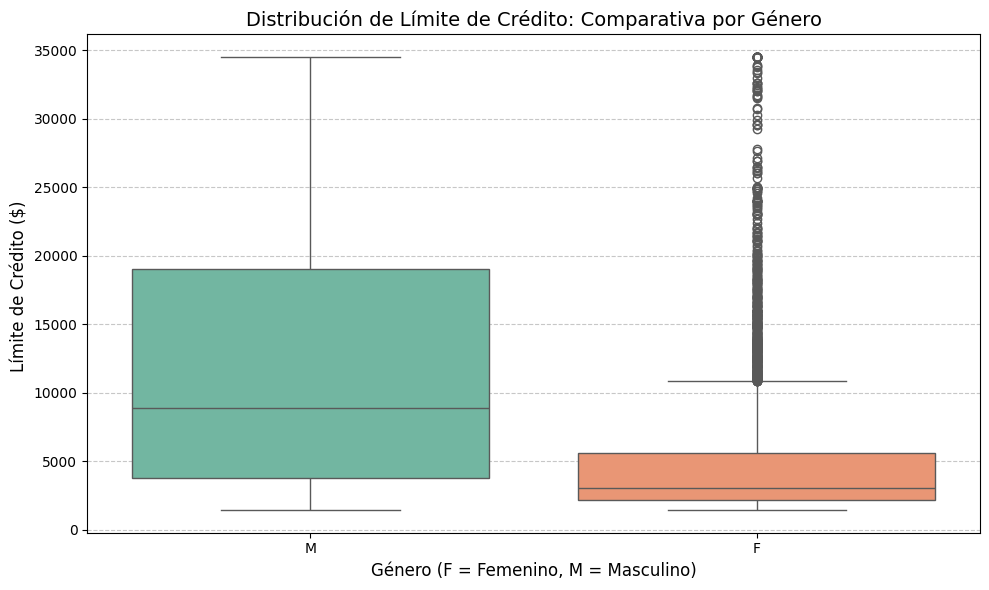

,Promedio,Mediana,Máximo
Gender,,,
F,5023.854274,3048.0,34516.0
M,12685.674963,8902.0,34516.0


In [ ]:
# Tópico 3: Análisis de Sesgo de Género
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

#Se eliminaron los warnings para mantener una mejor visualizacion del grafico
warnings.filterwarnings('ignore', category=FutureWarning)

# Configuramos el estilo visual
plt.figure(figsize=(10, 6))

# # Creación del gráfico de cajas para comparar distribuciones

# Agregamos hue='Gender' y legend=False para eliminar la advertencia de Seaborn v0.13+
sns.boxplot(x='Gender', y='Credit_Limit', data=df, palette='Set2', hue='Gender', legend=False)

# Creación del gráfico de cajas para comparar distribuciones
plt.title('Distribución de Límite de Crédito: Comparativa por Género', fontsize=14)
plt.xlabel('Género (F = Femenino, M = Masculino)', fontsize=12)
plt.ylabel('Límite de Crédito ($) ', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Cálculo numérico para el gráfico
resumen_genero = df.groupby('Gender')['Credit_Limit'].describe()[['mean', '50%', 'max']]
resumen_genero.columns = ['Promedio', 'Mediana', 'Máximo']
display(resumen_genero)

**¿Podemos inferir que hay un sesgo de género en el otorgamiento del límite de crédito de la tarjeta?**

Estadísticamente, sí existe una **disparidad** marcada en el límite de crédito entre hombres y mujeres. Al contrastar estos datos con el Nivel de Ingresos (Income_Category), **se observa que el límite de crédito mediano para los hombres es considerablemente superior**. Esto sugiere que la diferencia en el crédito no es una decisión arbitraria por género, sino que está **correlacionada** con los mayores niveles de ingresos reportados por el segmento masculino en esta muestra específica.

**¿El límite de crédito promedio es mayor para hombres o para mujeres?**

El **límite de crédito promedio** es significativamente mayor en hombres, situándose en **\$12,685.67**, mientras que el límite de crédito promedio para mujeres fue de **\$5,023.85**.

**¿Podríamos decir que hay un sesgo al dar líneas de crédito sólo con esta información?**

**Aunque los datos muestran una disparidad clara, no es posible afirmar un sesgo definitivo contando únicamente con este dataset.** Es necesario considerar variables críticas como el Historial Crediticio (Score), la antigüedad laboral y, de ser posible, los activos del cliente.

La ausencia de estas variables limita nuestra capacidad de inferencia; lo que observamos es una correlación entre ingresos y límites, pero no una causalidad de género. Se requeriría un análisis de 'Aceptados vs. Rechazados' para confirmar si existe una discriminación sistémica en el proceso de otorgamiento original.

**Tomando en cuenta las variables de la base de datos**.

**¿Cuál otra elegirías para descartar el sesgo de género en el otorgamiento de líneas de crédito y por qué?**

Eligiria la variable **Avg_Utilization_Ratio (Índice de Utilización)** para descartar el sesgo de género.

**¿Por qué?**

Al observar que el segmento masculino realiza un mayor volumen y monto de transacciones, el incremento en sus límites responde a una necesidad operativa para evitar la saturación de sus tarjetas.

Por el contrario, asignar límites altos a clientes con baja utilización (como se observa en el segmento femenino de esta muestra) sería financieramente ineficiente, ya que es capital "apartado" que no genera rendimientos. Así, la asignación de crédito resulta imparcial, ajustándose dinámicamente al uso real y la rentabilidad del banco, independientemente del género.

##**Tópico 4. Análisis predictivo**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# 1. Definición de variables
# X: Predictores (lo que explica el gasto) | y: Objetivo (lo que queremos predecir)
X = df[['Total_Trans_Ct', 'Total_Relationship_Count', 'Credit_Limit']]
y = df['Total_Trans_Amt']

# 2. División de datos (Train/Test)
# Usamos el 80% para enseñar al modelo y el 20% para evaluar su precisión real
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Creación y entrenamiento del modelo
modelo_transacciones = LinearRegression()
modelo_transacciones.fit(X_train, y_train)

# 4. Cálculo de la R-cuadrada
# Evaluamos con el set de prueba (X_test) para asegurar que el modelo funciona con datos nuevos
y_pred = modelo_transacciones.predict(X_test)
r_cuadrada = r2_score(y_test, y_pred)

print(f"La R-cuadrada del modelo es: {r_cuadrada:.4f}")

# 5. Predicción para el cliente específico
# Creamos un DataFrame con los mismos nombres de columnas para evitar el Warning de sklearn
nuevo_cliente = pd.DataFrame([[60, 3, 7500]],
                             columns=['Total_Trans_Ct', 'Total_Relationship_Count', 'Credit_Limit'])

prediccion_monto = modelo_transacciones.predict(nuevo_cliente)

print(f"El monto de transacciones predicho para el cliente es: ${prediccion_monto[0]:.2f}")

n = X_test.shape[0]  # Número de filas (2026)
p = X_test.shape[1]  # Número de variables (3)

r_ajustada = 1 - (1 - r_cuadrada) * (n - 1) / (n - p - 1)
print(f"La R-cuadrada Ajustada es: {r_ajustada:.4f}")

La R-cuadrada del modelo es: 0.6801
El monto de transacciones predicho para el cliente es: $4102.39
La R-cuadrada Ajustada es: 0.6797


**Predecir el monto de transacciones para un cliente con 60 transacciones, tres productos y un límite de crédito de \$7,500**

El modelo estima que el monto total de sus transacciones será de **$4,102.39.**

**¿Cuál es la R cuadrada del modelo?**

**0.6801**




###**Tópico 5. Analítica prescriptiva**

**En el conjunto de datos se encuentran los resultados un modelo para pronosticar El abandono de los clientes (churn rate).**
(Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1)

In [ ]:
# 1. Carga del archivo
df_temp = pd.read_excel('/content/BankChurners (1).xlsx')

# 2. Identifición de la columna del modelo (la que termina en _1 es Attrited/Abandono)
col_nb = [c for c in df_temp.columns if 'Naive_Bayes' in c and c.endswith('_1')][0]

# 3. Cálculo comparativo
# Segmento A: 3 meses o más de inactividad
tasa_inactivos = df_temp[df_temp['Months_Inactive_12_mon'] >= 3][col_nb].mean()

# Segmento B: Menos de 3 meses de inactividad
tasa_activos = df_temp[df_temp['Months_Inactive_12_mon'] < 3][col_nb].mean()

print(f"Tasa de abandono esperada (>= 3 meses inactivos): {tasa_inactivos:.2%}")
print(f"Tasa de abandono esperada (< 3 meses inactivos): {tasa_activos:.2%}")

# 4. Cálculo de la diferencia
factor = tasa_inactivos / tasa_activos
print(f"\nLa probabilidad de abandono es {factor:.2f} veces mayor en clientes con alta inactividad.")



Tasa de abandono esperada (>= 3 meses inactivos): 21.91%
Tasa de abandono esperada (< 3 meses inactivos): 11.11%

La probabilidad de abandono es 1.97 veces mayor en clientes con alta inactividad.


**¿Cómo es la tasa de abandono esperada de los clientes que tienen tres meses o más con respecto a la de los clientes con menos de tres meses de inactividad en los últimos doce meses?**

Hallazgo Clave de los Últimos 12 meses:
La inactividad trimestral es el principal precursor de fuga. Al comparar los segmentos de clientes en el último año, se observa un salto crítico en el riesgo:

Clientes Activos (< 3 meses inactivos): Tasa de abandono del **11.11%.**

Clientes Inactivos (≥ 3 meses inactivos): Tasa de abandono del **21.91%.**

Conclusión: Un cliente con 3 meses de inactividad acumulada tiene **1.97** veces más probabilidad de cancelar su cuenta que uno activo.

**¿Qué acciones que sean rentables para el negocio recomienda realizar para retenerlos?**

**Propuesta de Retención y Medición de Rentabilidad**

Tras analizar casos de éxito en el sector, se recomienda implementar una Estrategia de Domiciliación de Servicios (Pagos Recurrentes) para reducir el abandono en el segmento crítico (≥ 3 meses de inactividad). De acuerdo con consultoras como Bain & Company, esta acción puede reducir el churn hasta en un 50%, ya que genera una "barrera de salida operativa": el cliente percibe un costo de oportunidad y esfuerzo mayor al intentar cancelar una cuenta que ya tiene sus servicios básicos vinculados.

**¿Cómo mediría la rentabilidad de la acción que recomienda?**

Utilizaremos tres indicadores financieros (KPIs) para asegurar que el beneficio supere el costo del incentivo:

**Incremental Lift (Prueba A/B):**

Métrica: Comparar la facturación mensual (Total_Trans_Amt) de un grupo con servicios domiciliados vs. un grupo de control.

Umbral de Rentabilidad: La estrategia es exitosa si el margen transaccional recuperado cubre el costo del incentivo en un periodo menor a 4 meses.

**Extensión del Lifetime Value (LTV):**

Métrica: Cálculo de meses adicionales de permanencia. Un cliente con pagos recurrentes extiende su relación con el banco un promedio de 2.5 años.

Fórmula: (Meses de vida recuperados) x (Ingreso promedio mensual). Si el resultado es mayor al incentivo otorgado, la utilidad neta es positiva a largo plazo.

**Eficiencia frente al CAC (Cost of Acquisition):**

Análisis: Se contrasta el costo de retención (aprox. $200 ) contra el costo de adquirir un cliente nuevo (CAC), que oscila entre \$1,500 y \$3,000 en el sector bancario.

**Conclusión:** Retener mediante domiciliación es entre 5 y 10 veces más económico que la adquisición, optimizando el presupuesto de marketing del banco.